In [ ]:
import sys
from pathlib import Path
root = Path.cwd().parent 
sys.path.append(str(root))

from minio_utils import MinioSparkClient
import os
spark = MinioSparkClient(endpoint=os.getenv("MINIO_ENDPOINT", "").replace("http://", "").replace("https://", ""),
                        access_key=os.getenv("MINIO_ACCESS_KEY"),
                        secret_key=os.getenv("MINIO_SECRET_KEY"),
                        memory = 16,
                        heapsize = 8,
                        num_part = 2000,
                        bucket_name="pd2",
                        base_dir="cityenjoyer")
                        
spark.connect()

sc-20260313-160934-zrowd7 Dataproc Session is not active, stopping and creating a new one


████████████████████████████████                                                

In [66]:
import pyspark.sql.functions as f
from pyspark.sql.types import *
import math

In [ ]:
# Datos procesados sin outliers (casi)
df_agg = spark.read_parquet("21-25_clipped.parquet")
df_agg = df_agg.filter(f.year("pickup_datetime") == 2025)
df_agg.printSchema()

root
 |-- VendorID: byte (nullable = true)
 |-- pickup_datetime: timestamp_ntz (nullable = true)
 |-- dropoff_datetime: timestamp_ntz (nullable = true)
 |-- trip_distance: integer (nullable = true)
 |-- PULocationID: short (nullable = true)
 |-- DOLocationID: short (nullable = true)
 |-- payment_type: byte (nullable = true)
 |-- tip_amount: short (nullable = true)
 |-- tolls_amount: short (nullable = true)
 |-- fare_amount: short (nullable = true)
 |-- total_amount: short (nullable = true)



Join con datos de alquiler

In [ ]:
df_rent = spark.read_parquet("asking_rent_data.parquet")
df_rent = df_rent.filter(f.year("Date") == 2025)
df_rent.show(5)

  0%|           0/2 Tasks

+----------+-------------------+----------+
|LocationID|               Date|AskingRent|
+----------+-------------------+----------+
|         7|2025-01-01 00:00:00|    2650.0|
|         8|2025-01-01 00:00:00|    2650.0|
|       179|2025-01-01 00:00:00|    2650.0|
|       223|2025-01-01 00:00:00|    2650.0|
|         9|2025-01-01 00:00:00|    2700.0|
+----------+-------------------+----------+
only showing top 5 rows


In [ ]:
df_agg = df_agg.withColumn("month_key", f.trunc("pickup_datetime", "mon"))
df_rent = df_rent.withColumn("month_key", f.trunc("Date", "mon"))
df_rent = df_rent.withColumn("PULocationID", f.col("LocationID"))

df_agg = df_agg.join(
    f.broadcast(df_rent.select("month_key", "AskingRent", "PULocationID")),
    on=["month_key", "PULocationID"],
    how="inner"
).withColumnRenamed(
    "AskingRent", "PUAskingRent"
)

In [ ]:
df_rent = df_rent.withColumn("DOLocationID", f.col("LocationID"))

df_agg = df_agg.join(
    f.broadcast(df_rent.select("month_key", "AskingRent", "DOLocationID")),
    on=["month_key", "DOLocationID"],
    how="inner"
).withColumnRenamed(
    "AskingRent", "DOAskingRent"
)

Join con datos de localizaciones turísticas

In [ ]:
df_landmarks = spark.read_parquet("landmarks_per_zone.parquet")
df_landmarks.printSchema()

root
 |-- locationid: long (nullable = true)
 |-- landmark_count: long (nullable = true)



In [69]:
df_landmarks = df_landmarks.withColumns({
    "PULocationID": f.col("locationid").cast(ShortType()),
    "DOLocationID":f.col("locationid").cast(ShortType())
})

df_agg = df_agg.join(
    f.broadcast(df_landmarks.select("landmark_count", "PULocationID")),
    on="PULocationID",
    how="inner" #elimina outside NYC
).withColumnRenamed(
    "landmark_count", "PUlandmark_count"
)

df_agg = df_agg.join(
    f.broadcast(df_landmarks.select("landmark_count", "DOLocationID")),
    on="DOLocationID",
    how="inner"
).withColumnRenamed(
    "landmark_count", "DOlandmark_count"
)

Marcar los aeropuertos (mayor propina como se verá a continuación)

In [ ]:
df_agg = df_agg.withColumn("PUis_airport",
    f.col("PULocationID").isin([1, 4, 132]).cast(ByteType())
)
df_agg = df_agg.withColumn("DOis_airport",
    f.col("DOLocationID").isin([1, 4, 132]).cast(ByteType())
)

Añadir datos del mes, día de la semana y hora del día

In [ ]:
df_agg = df_agg.withColumn("hour", f.hour("pickup_datetime")) \
    .withColumn("dow", f.dayofweek("pickup_datetime")) \
    .withColumn("month", f.month("pickup_datetime"))
df_agg = df_agg.withColumn("hour", f.col("hour").cast(ByteType())) \
.withColumn("dow", f.col("dow").cast(ByteType())) \
.withColumn("month", f.col("month").cast(ByteType()))

In [ ]:
sel_cols = ["VendorID", "trip_distance", "payment_type", "PUAskingRent",
"DOAskingRent", "PUlandmark_count", "DOlandmark_count", "PUis_airport", "DOis_airport",
"dow", "hour", "month", "tip_amount"]
df_model_tip =  df_agg.select(sel_cols)
df_model_tip.cache()

In [ ]:
# df_agg = df_agg.withColumn("duration", f.timestamp_diff("SECOND", "pickup_datetime", "dropoff_datetime"))
# DESCARTO DURACIÓN YA QUE está bastante relacionado con distancia y no es posible obtener el dato con precisión antes del viaje

Análisis de null, solo tenemos en payment_type, se sustituye a "Unknown" = 5

In [ ]:
df_nulls = df_agg.select([
    f.sum(f.col(c).isNull().cast("int")).alias(c) for c in df_model_tip.columns
])

display(df_nulls.toPandas().T)

  0%|           0/142 Tasks

,0
VendorID,0
trip_distance,0
payment_type,43814
PUAskingRent,0
DOAskingRent,0
PUlandmark_count,0
DOlandmark_count,0
PUis_airport,0
DOis_airport,0
dow,0


In [ ]:
df_model_tip = df_model_tip.fillna({"payment_type": 5})
df_model_tip.cache()

DataFrame[VendorID: tinyint, trip_distance: int, payment_type: tinyint, PUAskingRent: double, DOAskingRent: double, PUlandmark_count: bigint, DOlandmark_count: bigint, PUis_airport: tinyint, DOis_airport: tinyint, dow: tinyint, hour: tinyint, month: tinyint, tip_amount: smallint]

In [ ]:
df_nulls = df_model_tip.select([
    f.sum(f.col(c).isNull().cast("int")).alias(c) for c in df_model_tip.columns
])

display(df_nulls.toPandas())

  0%|           0/140 Tasks

,VendorID,trip_distance,payment_type,PUAskingRent,DOAskingRent,PUlandmark_count,DOlandmark_count,PUis_airport,DOis_airport,dow,hour,hour_sin,hour_cos,month,tip_amount
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Medimos la simetría de las variables, vemos que hay que transformar la distancia. La variable objetivo se deja tal cual para no modificar sus unidades.

In [ ]:
df_model_tip.select(
    f.skewness("trip_distance").alias("skew_distancia"),
    f.skewness("PUAskingRent").alias("skew_PU_rent"),
    f.skewness("DOAskingRent").alias("skew_DO_rent"),
    f.skewness("tip_amount").alias("skew_tip")
).show()
## Como conclusión sacamos que hay que transformar trip_distance y la variable objetivo evitamos tener que transformarla usando un modelo GLM

  0%|           0/140 Tasks

+------------------+------------------+------------------+-----------------+
|    skew_distancia|      skew_PU_rent|      skew_DO_rent|         skew_tip|
+------------------+------------------+------------------+-----------------+
|2.8773949093503863|0.4382038161683976|0.4677735314403604|4.253216792859907|
+------------------+------------------+------------------+-----------------+



In [ ]:
# Transformamos la distancia con la raíz cúbica
df_model_tip = df_model_tip.withColumn(
    "trip_distance_cbrt", f.cbrt(f.col("trip_distance"))
)

df_model_tip.select(
    f.skewness("trip_distance_cbrt").alias("nueva_skew_dist")
).show()

  0%|           0/142 Tasks

+------------------+
|   nueva_skew_dist|
+------------------+
|0.6123143009882129|
+------------------+



Análisis de la correlación

  0%|           0/5 Tasks

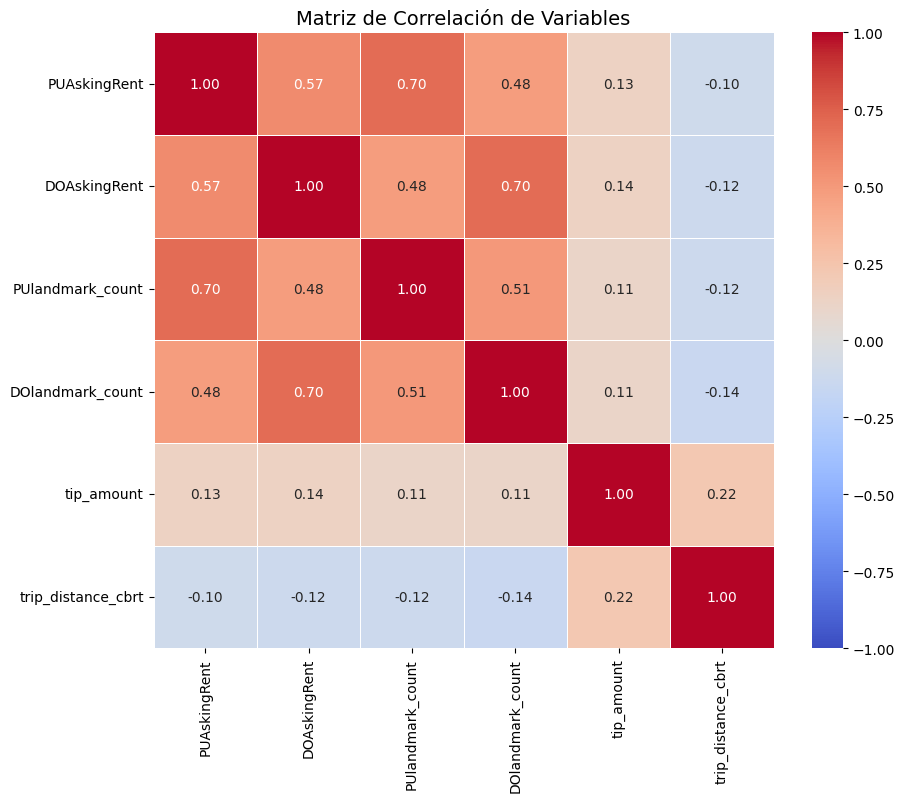

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import pandas as pd

columnas_numericas = [
    "PUAskingRent", "DOAskingRent",
    "PUlandmark_count", "DOlandmark_count",
    "tip_amount", "trip_distance_cbrt"
]

# 2. Empaquetamos en un vector (requisito de Spark ML)
assembler = VectorAssembler(
    inputCols=columnas_numericas,
    outputCol="features_corr",
    handleInvalid="skip" # Por si hay algún nulo rebelde
)
df_vector = assembler.transform(df_model_tip).select("features_corr")

# 3. Calculamos la matriz de Pearson
matriz_spark = Correlation.corr(df_vector, "features_corr", "pearson").head()[0]

# 4. TRUCO PRO: La pasamos a Pandas para poder leerla o pintarla en el notebook
corrmatrix_pandas = pd.DataFrame(matriz_spark.toArray(),
                                 columns=columnas_numericas,
                                 index=columnas_numericas)

# 1. Ajustamos el tamaño del lienzo para que no se vea apretado
plt.figure(figsize=(10, 8))

# 2. Pintamos el heatmap
sns.heatmap(
    corrmatrix_pandas,
    annot=True,        # Pinta el número exacto dentro de cada cuadrito
    cmap='coolwarm',   # Escala de colores rojo/azul
    fmt=".2f",         # Redondea a 2 decimales
    vmin=-1, vmax=1,   # Fuerza la escala matemática de Pearson (de -1 a 1)
    linewidths=0.5     # Le pone un bordecito a los cuadros para que quede elegante
)

plt.title("Matriz de Correlación de Variables", fontsize=14)
plt.show()

In [ ]:
df_model_tip.groupBy("PUis_airport").agg(
    f.mean("tip_amount").alias("tip_media"),
    f.stddev("tip_amount").alias("tip_sd"),
    f.count("*").alias("volumen_viajes")
).show()

  0%|           0/140 Tasks

+------------+-----------------+-----------------+--------------+
|PUis_airport|        tip_media|           tip_sd|volumen_viajes|
+------------+-----------------+-----------------+--------------+
|           1|456.9359519987404|721.2499975093974|       5843180|
|           0| 125.386870472408|297.6925474300509|     269445795|
+------------+-----------------+-----------------+--------------+



In [ ]:
df_model_tip.groupBy("DOis_airport").agg(
    f.mean("tip_amount").alias("tip_media"),
    f.stddev("tip_amount").alias("tip_sd"),
    f.count("*").alias("volumen_viajes")
).show()

  0%|           0/281 Tasks

+------------+------------------+-----------------+--------------+
|DOis_airport|         tip_media|           tip_sd|volumen_viajes|
+------------+------------------+-----------------+--------------+
|           1|351.92190167897576|699.3184277347085|       6320520|
|           0|127.26620523213401| 299.609135693966|     268968455|
+------------+------------------+-----------------+--------------+



In [ ]:
df_model_tip.groupBy("month").agg(
    f.mean("tip_amount").alias("tip_media"),
    f.stddev("tip_amount").alias("tip_sd"),
    f.count("*").alias("volumen_viajes")
).show()

  0%|           0/140 Tasks

+-----+------------------+------------------+--------------+
|month|         tip_media|            tip_sd|volumen_viajes|
+-----+------------------+------------------+--------------+
|    8|126.91855008465689| 308.9885933622365|      21795038|
|    3|129.64522689713849| 307.5179795984273|      23631986|
|    1|122.31508034536847| 286.8663676891312|      22951603|
|   10|148.00202447682983|335.01497141394617|      24586599|
|    2|118.73260243773841|282.12813393724383|      21991285|
|    9| 144.2506507801329|334.18765209361163|      22595573|
|   12|116.55524147901863| 327.8716110579031|      20909270|
|    7|129.82132835651322|310.57661015177973|      22497364|
|    4| 132.1403624557465|308.83401673822993|      22729561|
|    5|140.27124533236588| 332.7156579194771|      24589813|
|   11|138.30924214497483| 323.2577459466026|      23876849|
|    6|138.12572848297881|327.49839277313487|      23134034|
+-----+------------------+------------------+--------------+



In [ ]:
df_model_tip.groupBy("payment_type").agg(
    f.mean("tip_amount").alias("tip_media"),
    f.stddev("tip_amount").alias("tip_sd"),
    f.count("*").alias("volumen_viajes")
).show()

  0%|           0/281 Tasks

+------------+------------------+------------------+--------------+
|payment_type|         tip_media|            tip_sd|volumen_viajes|
+------------+------------------+------------------+--------------+
|           1| 423.5371873142587| 386.3861990770862|      28500660|
|           3|1.5826939591457492| 56.61392686598233|        284132|
|           4| 2.206815464565493| 64.89818240615017|       1008706|
|           2|0.1637115385017253|15.933409582203115|       4306807|
|           7|104.25802258068936| 296.3863254626551|     230759474|
|           0|30.354025598722508|141.16020357290267|      10385362|
|           5|152.61780809417348|289.81981608275476|         43834|
+------------+------------------+------------------+--------------+



In [ ]:
df_model_tip.groupBy("dow").agg(
    f.mean("tip_amount").alias("tip_media"),
    f.stddev("tip_amount").alias("tip_sd"),
    f.count("*").alias("volumen_viajes")
).show()

  0%|           0/281 Tasks

+---+------------------+------------------+--------------+
|dow|         tip_media|            tip_sd|volumen_viajes|
+---+------------------+------------------+--------------+
|  1| 119.5204663151777| 301.1800310779741|      38438380|
|  6|128.28039057666254|314.03159860855794|      42696253|
|  3|141.84904657326064| 324.6070525709502|      36048496|
|  2|136.83931047888785| 327.3506131334413|      34091719|
|  7|117.45053120968996|282.87444782325105|      44894983|
|  4|143.03664464898247|  329.105530923906|      39124157|
|  5|143.41795002958744| 336.8323759375972|      39994987|
+---+------------------+------------------+--------------+



In [ ]:
df_model_tip.groupBy("hour").agg(
    f.mean("tip_amount").alias("tip_media"),
    f.stddev("tip_amount").alias("tip_sd"),
    f.count("*").alias("volumen_viajes")
).show()

  0%|           0/281 Tasks

+----+------------------+------------------+--------------+
|hour|         tip_media|            tip_sd|volumen_viajes|
+----+------------------+------------------+--------------+
|  12|154.13419344685272| 341.3334111323128|      12365112|
|   1| 90.03197281655358|245.56939662930918|       6669353|
|   6|114.10465310115062| 320.5671482413285|       7180609|
|   3| 85.95841940510205|255.10325090670682|       3719764|
|   4|117.79963216492894| 335.5590107455454|       3803335|
|   8|116.97883826548399| 300.0967208988148|      13679597|
|  11|150.34789732582536| 331.4939090076688|      11990279|
|  19|128.32047648830525|291.62933385756827|      15956740|
|  23|111.28083654061643|281.80570305261057|      12547484|
|  21|130.87881754021745|296.23842177353157|      14663467|
|  14| 153.1417737909214|356.95593026124567|      13784071|
|  16|156.01329169449994|360.34561888838715|      14676684|
|  20|125.97374225024366| 288.5001253660315|      14930792|
|   5| 131.4087904281522|360.16859951411

In [ ]:
df_model_tip.groupBy("VendorID").agg(
    f.mean("tip_amount").alias("tip_media"),
    f.stddev("tip_amount").alias("tip_sd"),
    f.count("*").alias("volumen_viajes")
).show() # 0: yellow, 1: green, 2: Uber, 3: Lyft

  0%|           0/140 Tasks

+--------+------------------+------------------+--------------+
|VendorID|         tip_media|            tip_sd|volumen_viajes|
+--------+------------------+------------------+--------------+
|       3|112.33593386280468|296.05049568044194|      64285883|
|       2|101.13863495621958| 296.4570050669088|     166473591|
|       0|278.56154390392516| 371.8451264247403|      43995121|
|       1|263.94837381638536|337.19942875623354|        534380|
+--------+------------------+------------------+--------------+



Por último, vamos a ver cómo influyen las localizaciones turísticas (donde hay turistas que gustan de dar propinas) y las propinas.

In [72]:
df_model_tip.groupBy(f.col("DOlandmark_count") == 0).agg(
    f.mean("tip_amount").alias("tip_media"),
    f.stddev("tip_amount").alias("tip_sd"),
    f.count("*").alias("volumen_viajes")
).show()

  0%|           0/141 Tasks

Session is no longer active


+----------------------+-----------------+-----------------+--------------+
|(DOlandmark_count = 0)|        tip_media|           tip_sd|volumen_viajes|
+----------------------+-----------------+-----------------+--------------+
|                  true|122.8561079797234|358.5190272098885|      96935014|
|                 false|141.9629998033329|306.4760895250366|     180192826|
+----------------------+-----------------+-----------------+--------------+



In [73]:
df_model_tip.groupBy(f.col("DOlandmark_count") == 1).agg(
    f.mean("tip_amount").alias("tip_media"),
    f.stddev("tip_amount").alias("tip_sd"),
    f.count("*").alias("volumen_viajes")
).show()

  0%|           0/140 Tasks

+----------------------+------------------+------------------+--------------+
|(DOlandmark_count = 1)|         tip_media|            tip_sd|volumen_viajes|
+----------------------+------------------+------------------+--------------+
|                  true| 70.55186871555861|225.52529040968517|      41991998|
|                 false|146.83919918512467| 339.2667059506732|     235135842|
+----------------------+------------------+------------------+--------------+



In [74]:
df_model_tip.groupBy(f.col("DOlandmark_count") == 2).agg(
    f.mean("tip_amount").alias("tip_media"),
    f.stddev("tip_amount").alias("tip_sd"),
    f.count("*").alias("volumen_viajes")
).show()

  0%|           0/140 Tasks

+----------------------+------------------+------------------+--------------+
|(DOlandmark_count = 2)|         tip_media|            tip_sd|volumen_viajes|
+----------------------+------------------+------------------+--------------+
|                  true| 82.65248947037496|234.87236046764536|      12931847|
|                 false|137.85569912485388| 329.3445223653925|     264195993|
+----------------------+------------------+------------------+--------------+



In [75]:
df_model_tip.groupBy(f.col("DOlandmark_count") == 3).agg(
    f.mean("tip_amount").alias("tip_media"),
    f.stddev("tip_amount").alias("tip_sd"),
    f.count("*").alias("volumen_viajes")
).show()

  0%|           0/140 Tasks

+----------------------+-----------------+------------------+--------------+
|(DOlandmark_count = 3)|        tip_media|            tip_sd|volumen_viajes|
+----------------------+-----------------+------------------+--------------+
|                  true|105.0480578219639|251.35939025143057|       7314314|
|                 false|136.0992487418885| 327.4973648968202|     269813526|
+----------------------+-----------------+------------------+--------------+



In [76]:
df_model_tip.groupBy(f.col("DOlandmark_count") == 4).agg(
    f.mean("tip_amount").alias("tip_media"),
    f.stddev("tip_amount").alias("tip_sd"),
    f.count("*").alias("volumen_viajes")
).show()

  0%|           0/140 Tasks

+----------------------+------------------+-----------------+--------------+
|(DOlandmark_count = 4)|         tip_media|           tip_sd|volumen_viajes|
+----------------------+------------------+-----------------+--------------+
|                  true| 133.6820078039073|290.1717913913845|      11893273|
|                 false|135.35134753005252|327.2593682690307|     265234567|
+----------------------+------------------+-----------------+--------------+



In [77]:
df_model_tip.groupBy(f.col("DOlandmark_count") == 5).agg(
    f.mean("tip_amount").alias("tip_media"),
    f.stddev("tip_amount").alias("tip_sd"),
    f.count("*").alias("volumen_viajes")
).show()

  0%|           0/140 Tasks

+----------------------+------------------+-----------------+--------------+
|(DOlandmark_count = 5)|         tip_media|           tip_sd|volumen_viajes|
+----------------------+------------------+-----------------+--------------+
|                  true|141.07258600927932|288.4838873917636|       4149436|
|                 false|135.19165055269355|326.2875124401259|     272978404|
+----------------------+------------------+-----------------+--------------+



In [78]:
df_model_tip.groupBy(f.col("PUlandmark_count") == 6).agg(
    f.mean("tip_amount").alias("tip_media"),
    f.stddev("tip_amount").alias("tip_sd"),
    f.count("*").alias("volumen_viajes")
).show()

  0%|           0/140 Tasks

+----------------------+------------------+------------------+--------------+
|(PUlandmark_count = 6)|         tip_media|            tip_sd|volumen_viajes|
+----------------------+------------------+------------------+--------------+
|                  true| 95.30494097958065|250.70997674261977|       3960409|
|                 false|135.85926399476224| 326.6799076029158|     273167431|
+----------------------+------------------+------------------+--------------+



In [ ]:
df_model_tip.groupBy(f.col("PUlandmark_count") == 7).agg(
    f.mean("tip_amount").alias("tip_media"),
    f.stddev("tip_amount").alias("tip_sd"),
    f.count("*").alias("volumen_viajes")
).show()

  0%|           0/140 Tasks

+----------------------+------------------+-----------------+--------------+
|(PUlandmark_count = 7)|         tip_media|           tip_sd|volumen_viajes|
+----------------------+------------------+-----------------+--------------+
|                  true|175.47363584464375|318.1905414695496|       8145150|
|                 false|131.11163968697386|316.1817668915006|     267143825|
+----------------------+------------------+-----------------+--------------+



In [ ]:
df_model_tip.groupBy(f.col("PUlandmark_count") == 8).agg(
    f.mean("tip_amount").alias("tip_media"),
    f.stddev("tip_amount").alias("tip_sd"),
    f.count("*").alias("volumen_viajes")
).show()

  0%|           0/140 Tasks

+----------------------+-----------------+-----------------+--------------+
|(PUlandmark_count = 8)|        tip_media|           tip_sd|volumen_viajes|
+----------------------+-----------------+-----------------+--------------+
|                  true|152.9825844385849|295.3812983050255|       6807877|
|                 false|131.9029073510419|316.8265774396398|     268481098|
+----------------------+-----------------+-----------------+--------------+



In [79]:
df_model_tip.groupBy(f.col("DOlandmark_count") == 9).agg(
    f.mean("tip_amount").alias("tip_media"),
    f.stddev("tip_amount").alias("tip_sd"),
    f.count("*").alias("volumen_viajes")
).show()

  0%|           0/140 Tasks

+----------------------+------------------+-----------------+--------------+
|(DOlandmark_count = 9)|         tip_media|           tip_sd|volumen_viajes|
+----------------------+------------------+-----------------+--------------+
|                  true|140.03730664240217|309.6433416092082|        904477|
|                 false|135.26412733596325|325.8059481428291|     276223363|
+----------------------+------------------+-----------------+--------------+



In [80]:
df_model_tip.groupBy(f.col("DOlandmark_count") == 10).agg(
    f.mean("tip_amount").alias("tip_media"),
    f.stddev("tip_amount").alias("tip_sd"),
    f.count("*").alias("volumen_viajes")
).show()

  0%|           0/140 Tasks

+-----------------------+------------------+------------------+--------------+
|(DOlandmark_count = 10)|         tip_media|            tip_sd|volumen_viajes|
+-----------------------+------------------+------------------+--------------+
|                   true|197.37303014294034| 353.3877881105739|       7329212|
|                  false|  133.592910220433|324.80559519785345|     269798628|
+-----------------------+------------------+------------------+--------------+



In [81]:
df_model_tip.groupBy(f.col("PUlandmark_count") == 15).agg(
    f.mean("tip_amount").alias("tip_media"),
    f.stddev("tip_amount").alias("tip_sd"),
    f.count("*").alias("volumen_viajes")
).show()

  0%|           0/140 Tasks

+-----------------------+------------------+-----------------+--------------+
|(PUlandmark_count = 15)|         tip_media|           tip_sd|volumen_viajes|
+-----------------------+------------------+-----------------+--------------+
|                   true|222.77100416036507|402.7505576721828|       4750785|
|                  false|133.75368760044785|324.0399285163704|     272377055|
+-----------------------+------------------+-----------------+--------------+



In [ ]:
df_model_tip.groupBy(f.col("PUlandmark_count") == 21).agg(
    f.mean("tip_amount").alias("tip_media"),
    f.stddev("tip_amount").alias("tip_sd"),
    f.count("*").alias("volumen_viajes")
).show()

  0%|           0/140 Tasks

+-----------------------+------------------+-----------------+--------------+
|(PUlandmark_count = 21)|         tip_media|           tip_sd|volumen_viajes|
+-----------------------+------------------+-----------------+--------------+
|                   true|170.82710910463615|347.1424147504421|       5402731|
|                  false|131.65543589172333| 315.635503256371|     269886244|
+-----------------------+------------------+-----------------+--------------+



In [ ]:
df_model_tip.groupBy(f.col("PUlandmark_count") == 25).agg(
    f.mean("tip_amount").alias("tip_media"),
    f.stddev("tip_amount").alias("tip_sd"),
    f.count("*").alias("volumen_viajes")
).show()

  0%|           0/140 Tasks

+-----------------------+------------------+-----------------+--------------+
|(PUlandmark_count = 25)|         tip_media|           tip_sd|volumen_viajes|
+-----------------------+------------------+-----------------+--------------+
|                   true|180.31828649655702|324.7063897008901|       3505543|
|                  false|131.80645428747107|316.1738414797797|     271783432|
+-----------------------+------------------+-----------------+--------------+



In [ ]:
df_model_tip.printSchema()

root
 |-- DOLocationID: short (nullable = true)
 |-- PULocationID: short (nullable = true)
 |-- month_key: date (nullable = true)
 |-- VendorID: byte (nullable = true)
 |-- pickup_datetime: timestamp_ntz (nullable = true)
 |-- dropoff_datetime: timestamp_ntz (nullable = true)
 |-- trip_distance: integer (nullable = true)
 |-- payment_type: byte (nullable = false)
 |-- tip_amount: short (nullable = true)
 |-- tolls_amount: short (nullable = true)
 |-- fare_amount: short (nullable = true)
 |-- total_amount: short (nullable = true)
 |-- PUAskingRent: double (nullable = true)
 |-- DOAskingRent: double (nullable = true)
 |-- PUlandmark_count: long (nullable = true)
 |-- DOlandmark_count: long (nullable = true)
 |-- PUis_airport: byte (nullable = true)
 |-- DOis_airport: byte (nullable = true)
 |-- hour: byte (nullable = true)
 |-- dow: byte (nullable = true)
 |-- month: byte (nullable = true)
 |-- trip_distance_cbrt: double (nullable = true)



In [ ]:
final_cols = ["VendorID", "trip_distance_cbrt", "payment_type", "PUAskingRent",
"DOAskingRent", "PUlandmark_count", "DOlandmark_count", "PUis_airport", "DOis_airport",
"dow", "hour", "month", "tip_amount"]

In [ ]:
spark.write_parquet(df_model_tip.select(final_cols), "tip_model_data2/")

  0%|           0/140 Tasks